In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from PIL import Image, ImageOps
import os
from pathlib import Path

In [7]:
# Load CSV
df = pd.read_csv('shoe_annotations.csv')
unique_images = df['filename'].unique()
selected_images = random.sample(list(unique_images), 12)


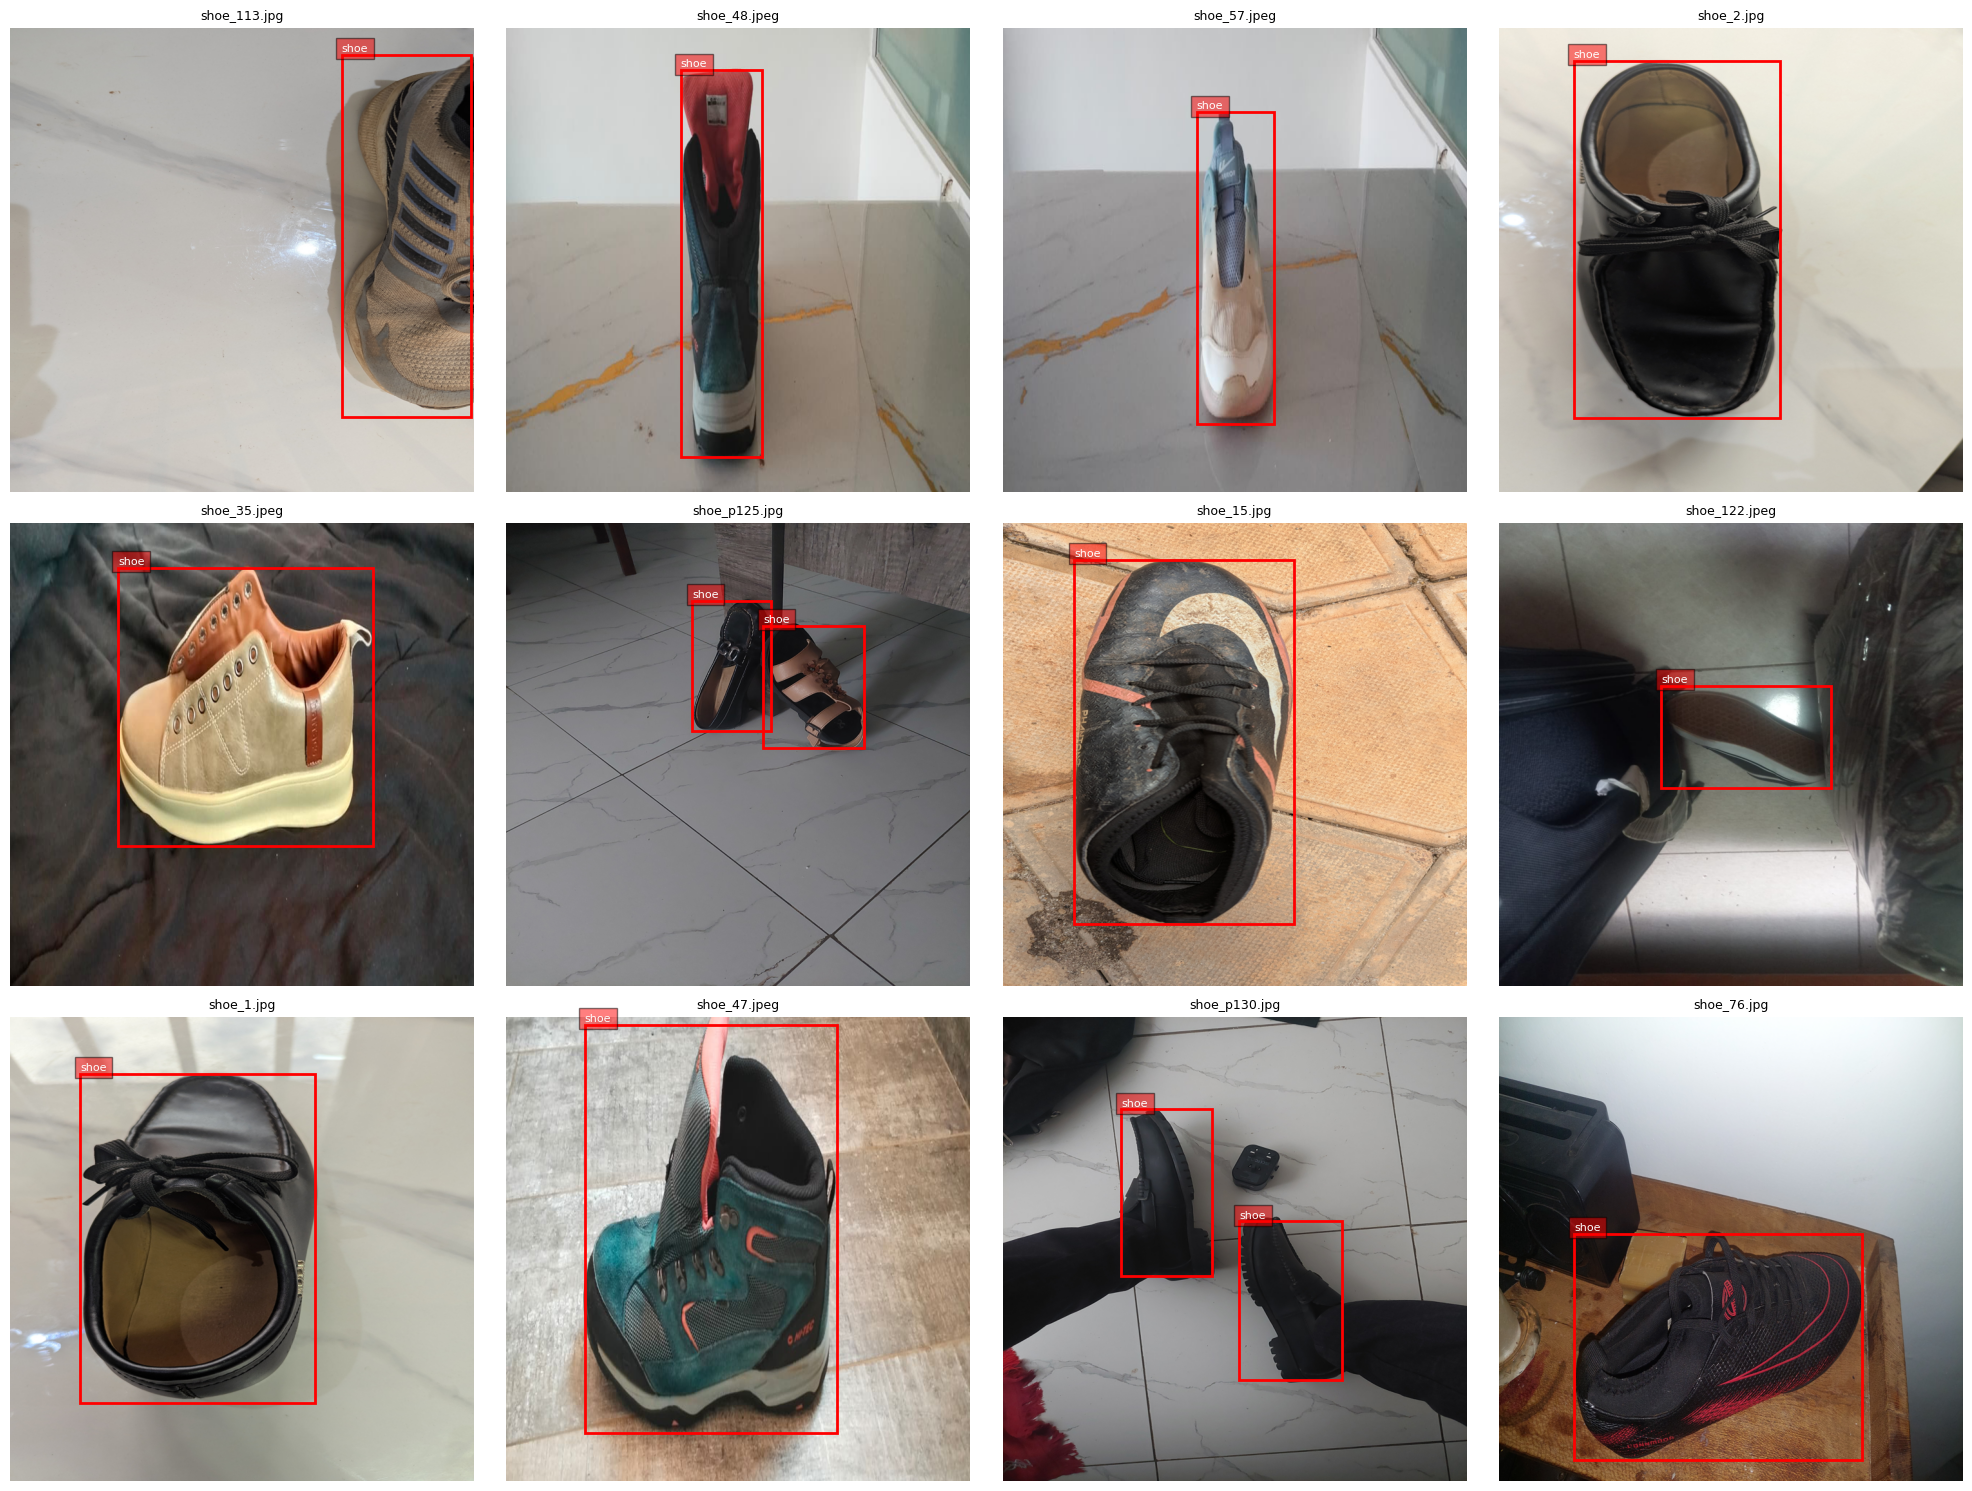

In [8]:
# Setup plot
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
TARGET_SIZE = 720

for i, filename in enumerate(selected_images):
    img_path = Path('data/raw') / filename
    
    if img_path.exists():
        # Open and immediately fix EXIF rotation
        img = Image.open(img_path)
        img = ImageOps.exif_transpose(img) 
        
        orig_w, orig_h = img.size
        
        # Resize and scale
        img_resized = img.resize((TARGET_SIZE, TARGET_SIZE))
        axes[i].imshow(img_resized)
        
        scale_x = TARGET_SIZE / orig_w
        scale_y = TARGET_SIZE / orig_h
    else:
        axes[i].text(0.5, 0.5, "File Not Found", ha='center', va='center', color='red')
        scale_x, scale_y = 1, 1

    # Filter and plot annotations
    image_anns = df[df['filename'] == filename]
    for _, row in image_anns.iterrows():
        new_xmin = row['xmin'] * scale_x
        new_ymin = row['ymin'] * scale_y
        new_w = row['width'] * scale_x
        new_h = row['height'] * scale_y

        rect = patches.Rectangle((new_xmin, new_ymin), new_w, new_h, 
                                 linewidth=2, edgecolor='r', facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(new_xmin, new_ymin - 5, row['class'], 
                     color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    axes[i].set_title(filename, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()